In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [ ]:
w, b = sp.symbols('w b')
x_data = np.array([1,2, 3, 4, 5])
y_data = np.array([15, 25, 30, 42, 50])
C = sum((w*xv + b - yv) ** 2 for xv, yv in zip(x_data, y_data)) / len(x_data)
print(sp.expand(C))

b**2 + 6*b*w - 324*b/5 + 11*w**2 - 1146*w/5 + 6014/5


In [ ]:
# bunda biz C(xatolik funksiyasi(MSE)) dan w(o'girlik) bo'yicha hosila olamiz
# bu bizga w ni qaysi tomonga o'zgartirsak, xatolik kamayishini ko'rsatadigan yo'nalishni beradi
dC_dw = sp.diff(C, w)

# bunda esa C dan b(bias) bo'yicha hosila olamiz, bu bizga siljish bo'yicha hosila oladi.
# umumiy maqsad gradientni topish(xatolik funksiyasini qiyalik burchagini topish)
dC_db = sp.diff(C, b)
print(dC_dw)
print(dC_db)

# qiymat berib qiyalikni topyapti, gradient qiymatini topyapti
print(float(dC_dw.subs({w: 0, b: 0})))
print(float(dC_db.subs({w: 0, b: 0})))

6*b + 22*w - 1146/5
2*b + 6*w - 324/5
-229.2
-64.8


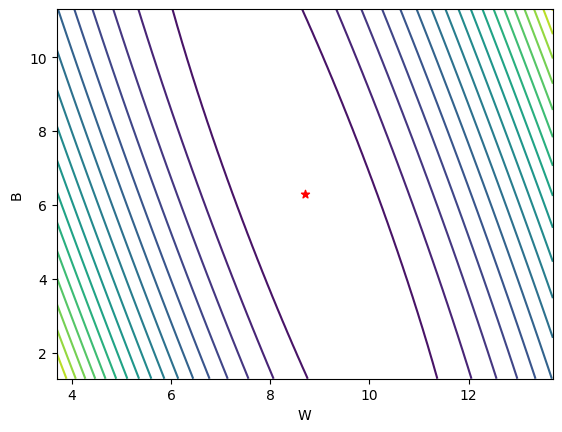

In [ ]:
cost = sp.lambdify((w, b), C, "numpy")
# lambdify sympy formatidagi C funcsiyasini numpy massivlari
# bilan tezkor ishlaydigan oddiy python funcsiyasiga aylantirib beradi.

sol = sp.solve([dC_dw, dC_db], [w, b])
# solve: hosilalarni nolga tenglab va eng kichik xatoni beruvchi w va b ni
# matematik usulda topadi.

w_opt, b_opt = float(sol[w]), float(sol[b]) # natijani o'nli songa o'zgartiryapti va saqlab qo'yyapti.
W, B = np.meshgrid(
    np.linspace(w_opt - 5, w_opt + 5, 100),
    np.linspace(b_opt - 5, b_opt + 5, 100)
)
plt.contour(W, B, cost(W, B), 20)
plt.scatter([w_opt], [b_opt], c='red', marker="*")
plt.xlabel('W')
plt.ylabel('B')
plt.show()

In [ ]:
x = np.array([1, 2, 3, 4, 5]);
y = np.array([15, 25, 30, 42, 50])
w, b = 0.0, 0.0
lr = 0.02
for step in range(200):
  pred = w*x + b
  dCdw = np.mean(2 * x * (pred - y))
  dCdb = np.mean(2 * (pred - y))
  w -= lr * dCdw
  b -= lr * dCdb
print(f"w={w:.3f}, b={b:.3f}, cost={cost(w, b):.3f}")

w=8.958, b=5.370, cost=1.817


In [ ]:
# ============================================================================================== #

In [ ]:
# 1-qadam: sigmoid funksiyasi va uning hosilasi
z = sp.symbols('z')
sigmoid = 1/(1+sp.exp(-z))
d_sigmoid = sp.diff(sigmoid, z)
print(sp.simplify(d_sigmoid))  # 1/(4*cosh(z/2)**2)
print(sp.simplify(d_sigmoid - sigmoid * (1 - sigmoid)))  # 0

1/(4*cosh(z/2)**2)
0


In [ ]:
# 2-qadam: chain role bilan gradientni chiqaramiz
w, x, y, b = sp.symbols('w x y b')
p = 1 / (1 + sp.exp(-(w*x + b)))
Loss = -(y*sp.log(p) + (1-y)*sp.log(1-p)) # binary cross-entropy
dLoss_dw = sp.diff(Loss, w)
print(sp.simplify(dLoss_dw - (p - y)*x)) # 0  -> dLoss/dw = (p-y)*x

0


In [ ]:
# 3-qadam: logistik regressiyani o'qitamiz
def sigmoid(z): return 1 / (1 + np.exp(-z))
x = np.array([1, 2, 3, 4, 5, 6, 7, 8])
y = np.array([0, 0, 0, 1, 0, 1, 1, 1])
w, b, lr = 0.0, 0.0, 0.1
for step in range(2000):
  pred = sigmoid(w * x + b)
  dw = np.mean((pred - y) * x)  # chain role natijasi!
  db = np.mean(pred - y)
  w -= lr * dw
  b -= lr * db
print(f"w={w:.3f}, b={b:.3f}")  # w=1.165, b=-5.198
print(np.round(sigmoid(w*x + b), 3)) # [0.017 0.054 0.154 0.369 0.652 0.857 0.951 0.984]

w=1.165, b=-5.198
[0.017 0.054 0.154 0.369 0.652 0.857 0.951 0.984]


In [ ]:
# ROC nuqtalarini modelning o'z ehtimolliklaridan hisoblaymiz
p = sigmoid(w*x+b)
tpr, fpr = [0.0], [0.0]

for t in np.sort(np.unique(p))[::-1]:  # chegaralar: kattadan kichikka
  pred = (p >= t).astype(int)
  tpr.append(np.sum((pred == 1) & (y == 1)) / np.sum( y == 1))
  fpr.append(np.sum((pred == 1) & (y == 0)) / np.sum(y == 0))

# Egri chiziq (1, 1) nuqtada tugashi uchun qo'shamiz
tpr.append(1.0)
fpr.append(1.0)

auc = np.trapezoid(tpr, fpr)
print(f"AUC -> {auc}")  # AUC -> 0.9375
# auc rate 0.5 da xato ishlaydi. undan katta bo'lishi kerak lekin u 0.5 ga teng bo'lmasligi kerak.
# ROC grafigini chizish
plt.plot(fpr, tpr, marker='o', color='blue', label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--') # Tasodifiy taxmin chizig'i
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Egri Chizig\'i')
plt.legend()
plt.grid()
plt.show()

AUC -> 0.9375


In [ ]:
from sklearn.metrics import roc_auc_score

# sklearn orqali AUC qiymatini hisoblaymiz
sklearn_auc = roc_auc_score(y, p)

print(f"Qo'lda hisoblangan AUC: {auc}")
print(f"Sklearn orqali hisoblangan AUC: {sklearn_auc}")
print(f"Natijalar mos keldimi?: {np.isclose(auc, sklearn_auc)}")


Qo'lda hisoblangan AUC: 0.9375
Sklearn orqali hisoblangan AUC: 0.9375
Natijalar mos keldimi?: True
